# EDA – Telco Customer Churn

Utforskande dataanalys inför modelleringen. Datan läses från samma SQLite-databas
som träningen och appen använder. Funktioner för aggregering återanvänds från src/eda.py.

In [55]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.data import NUMERIC_COLUMNS, TARGET_COLUMN
from src.db import load_customers
from src.eda import (
    EDA_CATEGORIES,
    churn_correlations,
    churn_rate_by,
    with_churn_flag,
)

pd.set_option("display.max_columns", None)

## 1. Inläsning

Datan läses från data/churn.db, samma källa som python -m src.train och appen.

In [56]:
df = load_customers()

print(f"{df.shape[0]} kunder, {df.shape[1]} kolumner")

df.head()

7043 kunder, 21 kolumner


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


load_customers() kör SELECT * FROM customers mot SQLite och ger en DataFrame med rådatan, innan clean() och add_features(). EDA:n visar först hur datan ser ut, sedan vad bearbetningen gör med den.

Observationer från head():
- customerID är identifierare, inte en egenskap. Den ska aldrig in i modellen.
- De flesta ja/nej-kolumner är text, men SeniorCitizen är redan 0/1. Därför ligger den bland de numeriska kolumnerna i src/data.py.
- Vissa kolumner har ett tredje värde utöver ja/nej, t.ex. No phone service i MultipleLines. Det gör att kolumnerna inte är rent binära utan behöver one-hot-kodas.
- tenure är antal månader som kund. Rad 0 har tenure 1 och TotalCharges = MonthlyCharges, vilket stämmer: totalt belopp = månader * månadskostnad.
- Churn är målvariabeln, Yes/No. Den mappas till 1/0 i src/data.py.

## 2. Första blicken: datatyper och saknade värden

Innan analysen behöver vi veta vilka kolumner som är numeriska, vilka som är kategoriska,
och om det saknas värden.

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Observationer från info():

- Bara tre kolumner är numeriska: SeniorCitizen,
  tenure, MonthlyCharges.
- TotalCharges är text trots att den ska vara ett tal.
  Något i kolumnen går alltså inte att tolka som tal.
- Inget värde är null. Men det betyder inte att inget
  saknas, en tom sträng räknas inte som null.

In [58]:
print(f"Unika customerID: {df['customerID'].nunique()} av {len(df)} rader")
print(f"Dubbletter: {df.duplicated().sum()}")

Unika customerID: 7043 av 7043 rader
Dubbletter: 0


In [59]:
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [60]:
categorical = df.select_dtypes(exclude="number").drop(columns=["customerID", "TotalCharges"])
for column in categorical:
    print(f"{column}: {sorted(categorical[column].unique())}")

gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn: ['No', 'Yes']


customerID är unikt och inga rader är dubbletter. Numeriska
värden är rimliga: tenure 0-72 månader, MonthlyCharges 18-119 kr,
SeniorCitizen bara 0/1.

Sex kolumner har värdet "No internet service" utöver Yes/No, och
MultipleLines har "No phone service". Kolumnerna är alltså inte
binära utan har tre värden, vilket kräver one-hot-kodning. De sex
internetkolumnerna är också de som summeras i num_addon_services.

Vilka värden i TotalCharges nedan går inte att tolka som tal?

In [61]:
as_number = pd.to_numeric(df["TotalCharges"], errors="coerce")
bad = df[as_number.isna()]

print(f"{len(bad)} rader med TotalCharges som inte är tal")
bad[["customerID", "tenure", "MonthlyCharges", "TotalCharges", TARGET_COLUMN]]

11 rader med TotalCharges som inte är tal


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Alla 11 rader har tenure = 0: kunder som precis
börjat och ännu inte fakturerats. TotalCharges är
en tom sträng, inte ett fel. Ingen av dem har churnat.

Hantering i src/data.py:
- clean() gör kolumnen numerisk och lämnar dessa
  som NaN.
- Pipelinen imputerar dem med medianen.

Alternativet vore att ta bort raderna. Vi behåller
dem: 11 av 7043 påverkar knappt något, och en ny kund
är exakt vad vi ska kunna prediktera på.

## 3. Målvariabeln: hur många churnar?

In [62]:
churn_counts = df[TARGET_COLUMN].value_counts()
churn_share = churn_counts / len(df)
pd.DataFrame({"antal": churn_counts, "andel": churn_share.round(3)})

,antal,andel
Churn,,
No,5174,0.735
Yes,1869,0.265


1869 av 7043 kunder (26,5 %) har churnat. Klasserna
är obalanserade: ungefär tre av fyra stannar.

Det får tre konsekvenser för modelleringen:
- Accuracy räcker inte. En modell som alltid
  gissar "No" får 73,5 % rätt utan att hitta en enda
  churnare. Därför utvärderar vi med precision,
  recall, F1 och ROC-AUC.
- class_weight="balanced" i src/models.py
  gör att en missad churnare kostar mer vid träning.
- Stratifierad split i src/train.py ger samma
  churn-andel i train, validation och test.

## 4. Kategoriska variabler mot churn

Churn-andel per kategori. Kolumnerna kommer från
EDA_CATEGORIES i src/eda.py.

In [63]:
churn_rate_by(df, "Contract")

,Contract,churn_andel,antal_kunder
0,Month-to-month,0.427097,3875
1,One year,0.112695,1473
2,Two year,0.028319,1695


- Avtalsform är en stark signal. Kunder med månadsavtal churnar i 42,7 % av fallen, kunder med ettårsavtal i 11,3 % och kunder med tvåårsavtal i 2,8 %. Ju längre bindningstid, desto lägre risk.
- Månadskunderna är också den största gruppen (3875 kunder), så det är där flest churnare finns.

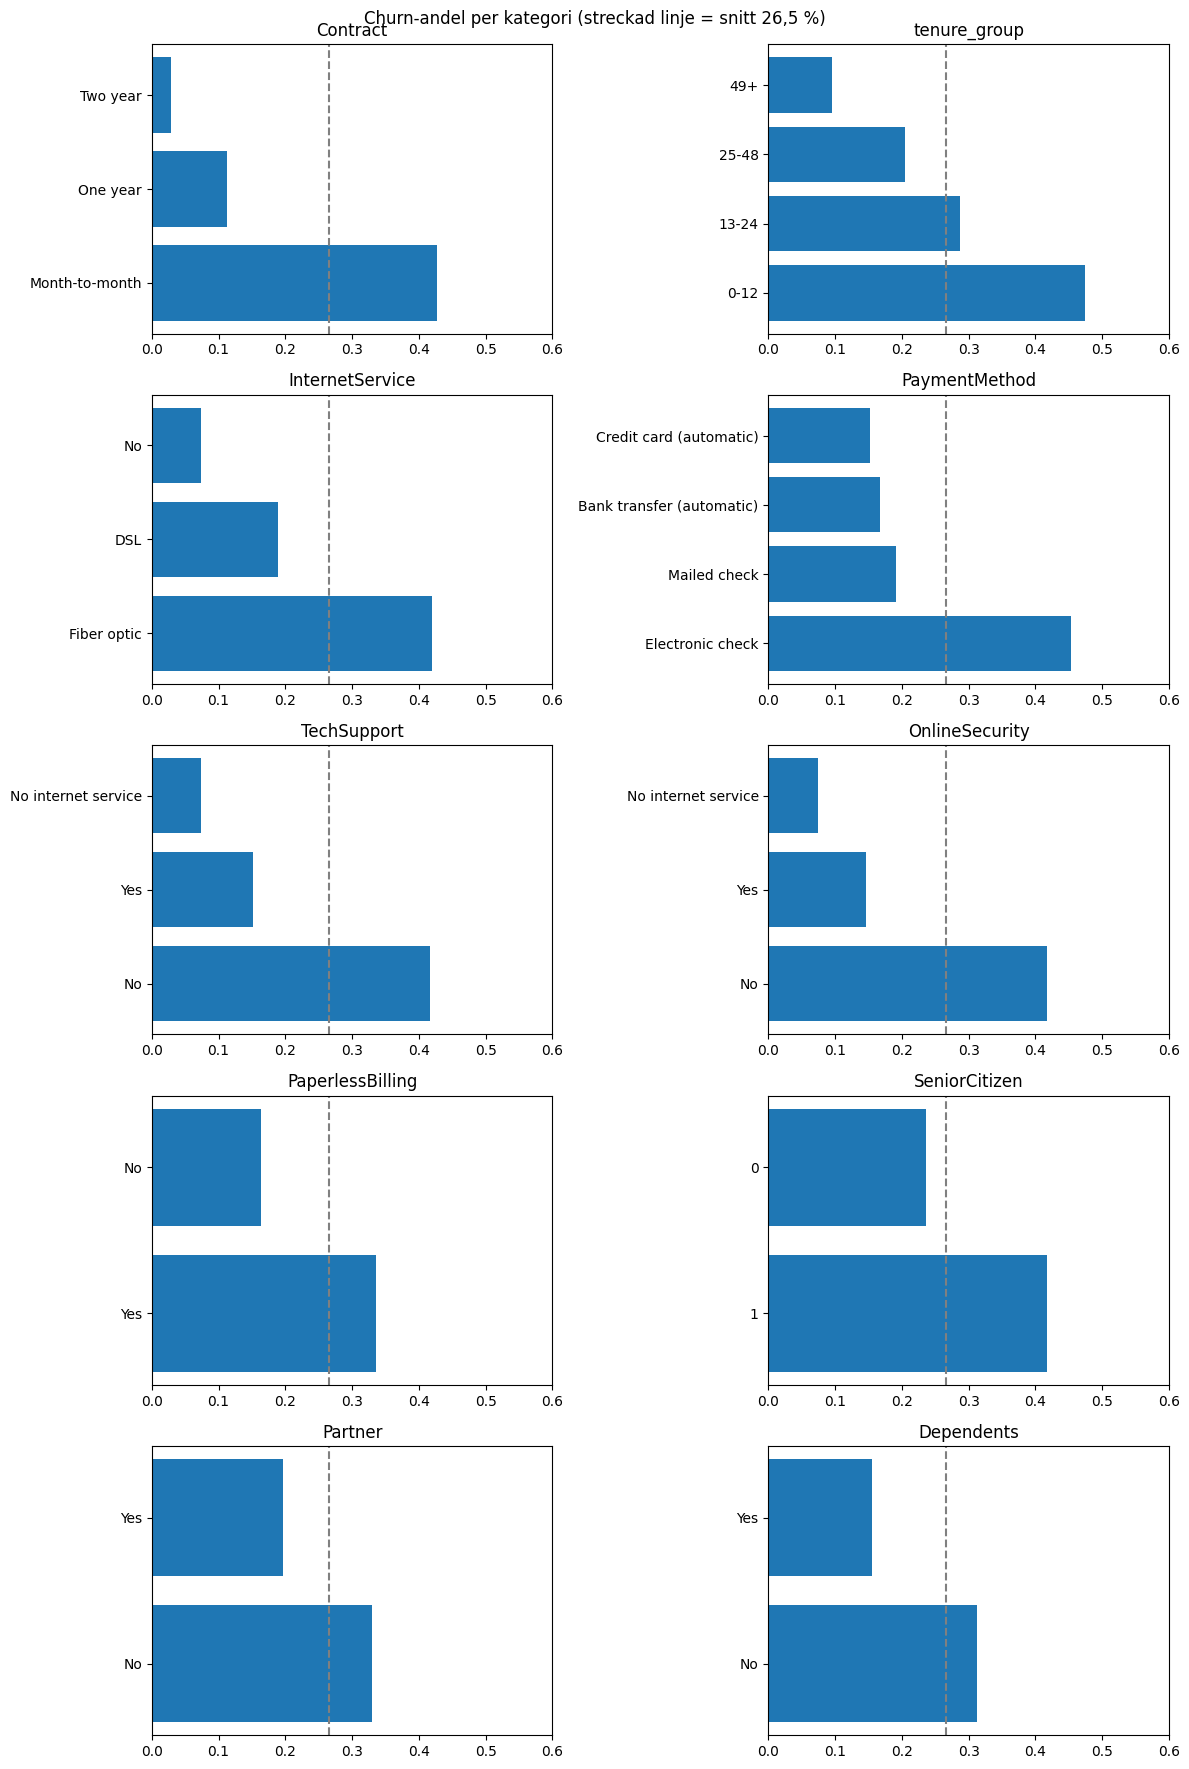

In [64]:
fig, axes = plt.subplots(5, 2, figsize=(12, 18))
for ax, column in zip(axes.flat, EDA_CATEGORIES, strict=True):
    rates = churn_rate_by(df, column)
    ax.barh(rates[column].astype(str), rates["churn_andel"])
    ax.set_title(column)
    ax.set_xlim(0, 0.6)
    ax.axvline(churn_share["Yes"], color="grey", linestyle="--")
fig.suptitle("Churn-andel per kategori (streckad linje = snitt 26,5 %)")
fig.tight_layout()
plt.show()

Fyra kolumner har en kategori med churn över 40 %:

- Contract: månadsavtal 42,7 %.
- tenure_group: första året 47 %. Andelen sjunker
  sedan för varje grupp, till under 10 % efter fyra år.
- InternetService: fiber 42 %, mot 19 % för DSL och
  7 % för kunder utan internet.
- PaymentMethod: e-check 45 %, mot 15-19 % för övriga.
  De automatiska betalsätten har lägst churn.

TechSupport och OnlineSecurity visar samma mönster:
kunder som har internet men saknar tjänsten churnar
i över 40 %, kunder som har tjänsten i cirka 15 %.
Tilläggstjänster verkar alltså binda kunden.

Svagare men tydliga skillnader finns för
PaperlessBilling, SeniorCitizen, Partner och
Dependents. Kunder utan partner eller barn, äldre
kunder och kunder med pappersfri faktura churnar
något mer än snittet.

Sammantaget: churn är koncentrerad till nya kunder
med månadsavtal, fiber, e-check och få tilläggstjänster.

## 5. Numeriska variabler mot churn

clean() gör TotalCharges numerisk, sedan lägger vi på en 0/1-kolumn för churn och jämför fördelningen av de tre beloppskolumnerna för de som stannat respektive lämnat.
describe() ger antal, medel, spridning och kvartiler medan T vänder tabellen så den blir läsbar.

In [65]:
clean_df = with_churn_flag(df)
clean_df.groupby("churn")[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T.round(1)

churn                      0       1
tenure         count  5174.0  1869.0
               mean     37.6    18.0
               std      24.1    19.5
               min       0.0     1.0
               25%      15.0     2.0
               50%      38.0    10.0
               75%      61.0    29.0
               max      72.0    72.0
MonthlyCharges count  5174.0  1869.0
               mean     61.3    74.4
               std      31.1    24.7
               min      18.2    18.8
               25%      25.1    56.2
               50%      64.4    79.6
               75%      88.4    94.2
               max     118.8   118.4
TotalCharges   count  5163.0  1869.0
               mean   2555.3  1531.8
               std    2329.5  1890.8
               min      18.8    18.8
               25%     577.8   134.5
               50%    1683.6   703.6
               75%    4264.1  2331.3
               max    8672.4  8684.8

Tabellen jämför fördelningen av de tre numeriska
kolumnerna för kunder som stannat (0) och churnat (1).

Tenure. Här är skillnaden störst. Halva gruppen som
churnat gjorde det inom 10 månader, och en fjärdedel
inom 2 månader. Bland de som stannat har hälften varit
kunder i över 38 månader. Båda grupperna når max 72,
så datan täcker sex år, men churnarna ligger nästan
helt i början av den perioden. Churn är alltså i
första hand något som sker tidigt i kundrelationen.
Klarar kunden det första året sjunker risken kraftigt,
vilket stämmer med grafen för tenure_group ovan.

MonthlyCharges. Churnare betalar mer per månad, median
79,6 mot 64,4, men det intressanta är spridningen.
Bland de som stannar ligger den nedre kvartilen på
25,1, alltså finns många billiga kunder som stannar.
Bland churnarna ligger den på 56,2. Kunder med låg
månadskostnad churnar sällan. Det är i praktiken
kunder med bara telefoni och utan internet, vilket
förklarar den låga andelen för InternetService = No.
Churn är alltså inte bara ett prisproblem utan
kopplat till vilken typ av tjänst kunden har.

TotalCharges. Churnare har lägre totalt belopp trots
högre månadskostnad. Det är ingen egen signal utan en
följd av kort tenure: totalt belopp är ungefär tenure
gånger MonthlyCharges. Kolumnen är därför starkt
korrelerad med tenure, något vi kontrollerar i
avsnitt 6. För trädmodeller spelar det liten roll,
för logistisk regression kan det göra koefficienterna
svårare att tolka.

Count för TotalCharges är 5163, inte 5174. Det är de
11 nya kunderna som blivit NaN efter clean() och som
pipelinen imputerar med medianen.

Slutsats för modelleringen: tenure och MonthlyCharges
är de två viktigaste numeriska variablerna, och de
fångar olika saker: hur länge kunden funnits och vad
kunden har för tjänst. TotalCharges tillför lite
utöver dem.

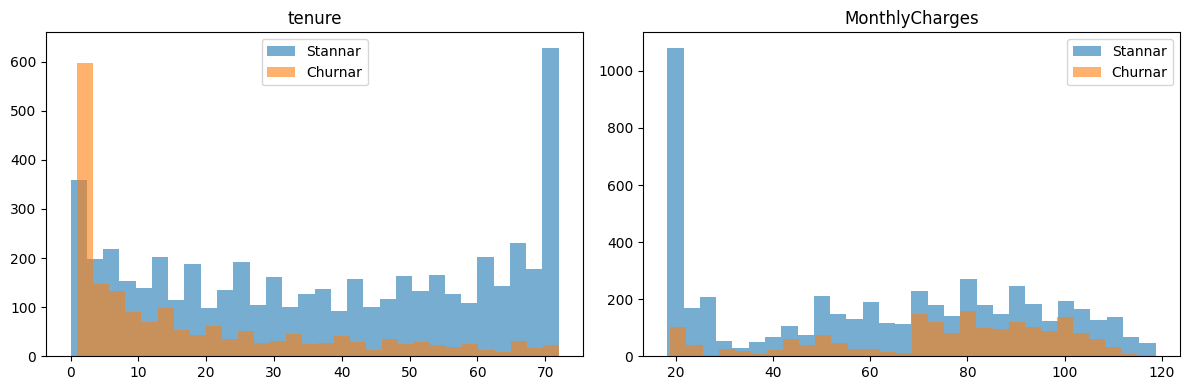

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, column in zip(axes, ["tenure", "MonthlyCharges"], strict=True):
    for value, label in [(0, "Stannar"), (1, "Churnar")]:
        subset = clean_df.loc[clean_df["churn"] == value, column]
        ax.hist(subset, bins=30, alpha=0.6, label=label)
    ax.set_title(column)
    ax.legend()
fig.tight_layout()
plt.show()

Tabellen ovan visar siffror, en graf visar formen på fördelningen. Nu blir mönstret lite mer uppenbart.

Tenure. Churnarna (orange) har en hög topp vid 1-2
månader och avtar sedan snabbt. De som stannar har
i stället två toppar: en vid 0-5 månader (nya kunder
som ännu inte hunnit lämna) och en vid 70-72 månader
(långvariga kunder). Datan slutar vid 72 månader,
så den högra toppen är alla som funnits sedan
mätperiodens början. Mellan topparna är fördelningen
ungefär platt. Bilden bekräftar att churn framför
allt inträffar de första månaderna.

MonthlyCharges. De som stannar har en mycket hög
topp kring 20, vilket är kunder med enbart telefoni.
Nästan inga churnare finns där. Churnarna ligger i
stället samlade mellan 70 och 105, det prisintervall
där fiberkunder hamnar. Fördelningen för churn följer
alltså tjänstetypen snarare än priset i sig.

De två variablerna skiljer grupperna åt på olika
sätt: tenure genom när i kundrelationen kunden
befinner sig, MonthlyCharges genom vilken tjänst
kunden har. Det gör dem till bra komplement i
modellen.

In [67]:
bins = [0, 30, 50, 70, 90, 110, 130]
labels = ["18-30", "30-50", "50-70", "70-90", "90-110", "110-130"]
price_band = pd.cut(clean_df["MonthlyCharges"], bins=bins, labels=labels)
by_price = clean_df.groupby(price_band, observed=True)["churn"].agg(["mean", "size"])
by_price.columns = ["churn_andel", "antal_kunder"]
by_price.round(3)

,churn_andel,antal_kunder
MonthlyCharges,,
18-30,0.098,1653
30-50,0.308,646
50-70,0.208,1161
70-90,0.378,1844
90-110,0.356,1524
110-130,0.130,215


Churn följer inte priset rakt av. Andelen går upp
och ner mellan intervallen:

- 18-30 kr: 9,8 %. Enbart telefoni, låg churn.
- 30-50 kr: 30,8 %. Troligen DSL utan tilläggs-
  tjänster, alltså kunder med internet men utan
  något som binder dem.
- 50-70 kr: 20,8 %. DSL med tjänster eller telefoni
  med flera linjer, lägre churn igen.
- 70-110 kr: 36-38 %. Här ligger fiberkunderna, och
  här är churn högst. Det är också de två största
  grupperna, med 3368 kunder tillsammans.
- 110-130 kr: 13,0 %. De dyraste kunderna churnar
  lite. De har fiber plus många tilläggstjänster,
  och sannolikt längre avtal.

Hade priset i sig drivit churn skulle andelen stiga
för varje intervall. I stället toppar den två gånger
och faller i slutet. Det talar för att det är
tjänstepaketet som avgör, inte kronorna. Kunder med
få tjänster som binder dem churnar mest, oavsett om
paketet är billigt eller dyrt.

Datan visar samband per prisnivå, inte effekten av
en prisändring. Det senare kräver prishistorik per
kund, vilket saknas i datan.

## 6. Korrelationer

Koden beräknar korrelationen mellan varje numerisk kolumn och churn (0/1), sorterat från mest negativ till mest positiv, med hjälp av gruppens funktion i src/eda.py


In [68]:
churn_correlations(df)

tenure               -0.352229
TotalCharges         -0.199484
num_addon_services   -0.087698
SeniorCitizen         0.150889
avg_monthly_charge    0.192033
MonthlyCharges        0.193356
dtype: float64

Tenure har starkast samband med churn (-0,35): ju
längre kundtid, desto lägre risk. TotalCharges följer
(-0,20), men det är till stor del samma information
eftersom totalt belopp växer med tenure.

MonthlyCharges (0,19) och SeniorCitizen (0,15) drar
åt andra hållet: högre månadskostnad och äldre kunder
churnar mer.

avg_monthly_charge (0,192) ligger nästan exakt på
MonthlyCharges (0,193). De två kolumnerna verkar bära
samma information, vilket heatmapen nedan visar.

num_addon_services har svagt samband (-0,09) trots
att TechSupport och OnlineSecurity visade stora
skillnader i avsnitt 4. Två skäl: kunder utan
internet har noll tjänster men låg churn, och
streamingtjänsterna minskar inte churn på samma sätt
som säkerhet och support. Sambandet är alltså inte
linjärt, och då underskattar korrelationen det.

Inget värde är över 0,4. Ingen enskild numerisk
kolumn räcker för att förutsäga churn, det är
kombinationen med de kategoriska variablerna som
gör jobbet.

Nu kollar vi hur de numeriska kolumnerna hänger ihop med varandra, inte bara med churn.

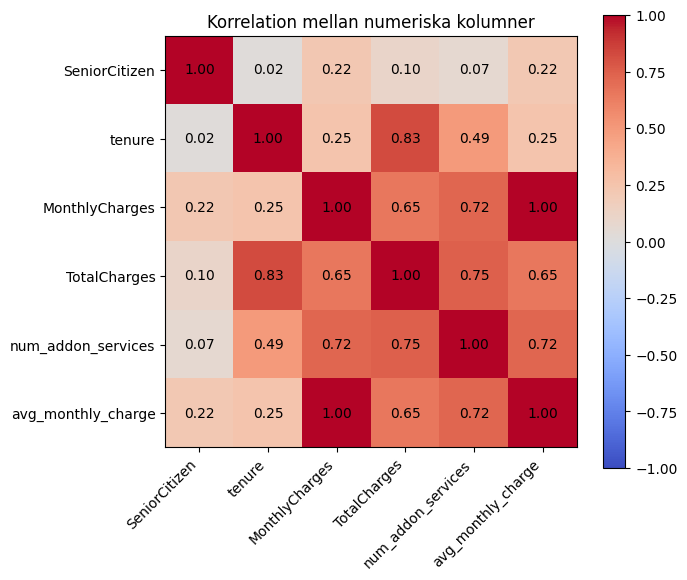

In [69]:
numeric = clean_df[NUMERIC_COLUMNS]
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax)
ax.set_title("Korrelation mellan numeriska kolumner")
fig.tight_layout()
plt.show()

Tre par sticker ut:

- MonthlyCharges och avg_monthly_charge: 1,00. De är
  i praktiken samma kolumn. avg_monthly_charge var
  tänkt att visa om priset ändrats över kundtiden,
  men i det här datasettet har det inte hänt. Den
  härledda kolumnen tillför alltså inget.
- tenure och TotalCharges: 0,83. Väntat, eftersom
  totalt belopp är ungefär tenure gånger månadskostnad.
- num_addon_services och MonthlyCharges: 0,72. Fler
  tjänster ger högre faktura. Kolumnen mäter delvis
  samma sak som priset.

Starkt korrelerade kolumner skadar inte trädmodeller,
men för logistisk regression gör de koefficienterna
instabila och svåra att tolka: modellen kan inte
skilja på vilken av två identiska kolumner som
förklarar effekten.

## 7. Tillför de härledda kolumnerna något?

add_features() skapar tre kolumner: num_addon_services,
avg_monthly_charge och tenure_group. Korrelationerna
ovan väcker frågan om de ger modellen ny information.

Koden nedan mäter hur mycket avg_monthly_charge faktiskt skiljer sig från MonthlyCharges per kund, för att avgöra om kolumnen bär någon egen information.

In [70]:
features = clean_df
diff = (features["avg_monthly_charge"] - features["MonthlyCharges"]).abs()
share = (diff > 1).mean()
print(f"Kunder där snittkostnad avviker mer än 1 kr från månadskostnad: {share:.1%}")
diff.describe().round(2)

Kunder där snittkostnad avviker mer än 1 kr från månadskostnad: 54.9%


count    7032.00
mean        1.75
std         1.95
min         0.00
25%         0.43
50%         1.15
75%         2.40
max        19.13
dtype: float64

Mer än hälften av kunderna avviker med över 1 kr, men
avvikelserna är små: median 1,15 kr och max 19 kr på
månadskostnader mellan 18 och 119 kr. Det är
avrundningar och delmånader, inte prisändringar.
Därför blir korrelationen 1,00 och kolumnen tillför
inget som MonthlyCharges inte redan har.

De två andra härledda kolumnerna bedöms så här:

- tenure_group. För trädmodeller tillför den inget,
  de hittar egna brytpunkter i tenure. För logistisk
  regression kan den däremot hjälpa: sambandet mellan
  tenure och churn är inte linjärt (hög risk första
  året, sedan platt), och gruppindelningen låter
  modellen fånga det med en koefficient per grupp.
  Den är också det tydligaste sättet att visa
  mönstret i EDA och app.
- num_addon_services. Summan av sex kolumner modellen
  redan ser. Korrelationen mot MonthlyCharges är 0,72,
  så den bär delvis samma information som priset.
  Sambandet med churn är svagt (-0,09). Tillför lite,
  men skadar inte.

Rekommendation till gruppen: avg_monthly_charge kan
tas bort ur ENGINEERED_NUMERIC_COLUMNS utan att
modellen förlorar något. tenure_group behålls.
num_addon_services kan behållas men bör inte
motiveras som en stark signal.

## 8. Slutsatser för modelleringen

Vad datan säger:

- 7043 kunder, 21 kolumner, 26,5 % churn. Enda
  datakvalitetsproblemet är 11 nya kunder utan
  TotalCharges, som imputeras med medianen.
- Churn är koncentrerad till nya kunder med
  månadsavtal, fiber, e-check och utan säkerhets-
  eller supporttjänster. Risken är högst de första
  månaderna och sjunker sedan kraftigt.
- Contract, tenure och InternetService är de
  starkaste enskilda signalerna. Ingen av dem
  räcker ensam.
- Churn följer tjänstepaketet, inte priset i sig.
  Både billiga och dyra kunder med få bindande
  tjänster churnar mer än de däremellan.

Vad det betyder för modellen:

- Obalansen motiverar class_weight="balanced",
  stratifierad split och utvärdering med ROC-AUC,
  precision och recall i stället för accuracy.
- Kategoriska kolumner med tre värden kräver
  one-hot, vilket pipelinen i src/features.py gör.
- Flera numeriska kolumner mäter samma sak. Det
  påverkar tolkningen av logistisk regression men
  inte trädmodellernas prestanda.
- avg_monthly_charge är redundant och kan tas bort.
  tenure_group behålls, num_addon_services är svag
  men ofarlig.

Vad det betyder för verksamheten:

- Insatser mot churn bör riktas mot det första
  kundåret och mot månadskunder med fiber utan
  tilläggstjänster.
- Bindningstid, automatisk betalning och säkerhets-
  eller supporttjänster hänger ihop med lägre churn.
  EDA:n visar samband, inte orsak: vi vet inte om
  tjänsterna håller kvar kunden eller om lojala
  kunder väljer fler tjänster.